# **Vicente Olea**



# Notebook métricas de evaluación con RR Lyrae

Basado en Machine learning for physics and Astronomy, Viviana Acquaviva (2023)

En esta actividad trabajaremos con un problema de clasificación binaria: distinguir estrellas **RR Lyrae** de otras estrellas a partir de sus colores fotométricos.

### Los objetivos son
- entrenar un clasificador simple
- evaluar su rendimiento con distintas métricas
- interpretar una matriz de confusión
- comparar accuracy con precision, recall y F1
- discutir qué métrica conviene según el objetivo científico

### Contexto
Las RR Lyrae son estrellas variables pulsantes muy importantes en astronomía. En un catálogo grande, un clasificador puede ayudarnos a encontrar candidatas RR Lyrae, pero no basta con mirar solo el accuracy.


### Descripción de los datos
El set de datos que usará para esta tarea es sobre estrellas. Las características son colores en distintos filtros del [sistema ugriz de SDSS](https://www.physics.unlv.edu/~jeffery/astro/photometry/photometry_sdss.html), que son un indicador si la estrella emite luz más azul, verde, amarilla o roja. Queremos predecir a partir de estas características si la estrella es un tipo especial de estrella llamada variable RR Lyrae.

- Las características son los colores u-g, g-r, r-i, i-z
- El target es 0 (no RRLyrae) y 1 (RRLyrae)


In [51]:
import pandas as pd
import numpy as np

import sklearn.tree
from sklearn.tree import DecisionTreeClassifier #modelo
from sklearn.tree import plot_tree #visualizacion arbol
from sklearn.model_selection import train_test_split
from sklearn import metrics #métricas
from sklearn.model_selection import cross_val_predict, cross_val_score, cross_validate #validación cruzada
from sklearn.model_selection import KFold, StratifiedKFold #validación cruzada

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay #matriz de confusión


from scipy import stats

In [52]:
from io import StringIO
from IPython.display import Image
import pydotplus
from sklearn.tree import export_graphviz

In [53]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

font = {'size': 8}

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=8)
matplotlib.rc('ytick', labelsize=8)
matplotlib.rcParams['figure.dpi'] = 300

pd.set_option('display.max_columns', 100) #Para poder visualizar todas las columnas del dataframe
pd.set_option('display.max_colwidth', 100)

## Primer paso: exploración de los datos

Siempre es importante hacer una análisis exploratorio del conjunto de datos que trabajaremos. Leemos el archivo como un dataframe y extraemos información básica

In [54]:
#from google.colab import drive
#drive.mount('/content/drive')

In [55]:

#cargamos los datos como arreglos numpy
features= np.loadtxt("RRLyrae_features_small.txt", delimiter=',')
targets= np.loadtxt("RRLyrae_labels_small.txt", delimiter=',')


In [56]:
columnas = ["u-g", "g-r", "r-i", "i-z"]
df = pd.DataFrame(features, columns=columnas)
df["RR_Lyrae"] = targets.astype(int)

df.head()

,u-g,g-r,r-i,i-z,RR_Lyrae
0,0.311,0.714,0.093,0.204,0
1,0.332,0.965,0.122,0.032,0
2,0.394,1.019,0.147,0.096,0
3,0.285,0.865,0.120,0.039,0
4,0.386,0.977,0.181,0.080,0


In [57]:
print(df["RR_Lyrae"].value_counts())

RR_Lyrae
0    2000
1     483
Name: count, dtype: int64


### Preguntas
1. ¿Este es un problema de clasificación o regresión?

Clasificación, ya que buscamos asignar una categoría a cada estrella.

2. ¿Es un problema binario o multiclase?

Es un problema binario, donde 0 corresponde a la asignación de no pertenecer a las RR Lyrae y 1 a las que si pertenecen.

3. ¿Qué representa la variable objetivo?

RR_Lyrae indica si la estrella pertenece o no a la clase RR Lyrae

4. ¿Las clases están balanceadas o desbalanceadas?

Están desbalanceadas. La gran mayoría de los datos corresponde a la clase de estrellas que no son RR Lyrae (2000) ~ 80% , mientras que hay una cantidad mucho menor para la clase que si son RR Lyrae (483) ~20%.a

5. ¿Por qué esto podría ser importante al elegir una métrica de evaluación?

Porque el accuracy podría parecer alto simplemente por clasificar de forma correcta la clase mayoritaria. Por lo que necesitamos estudiar adicionalmente precision, recall y F1 score.

#### Haga una visualización de sólo dos columnas para revisar los colores de las RR Lyrae y las no RRLyrae

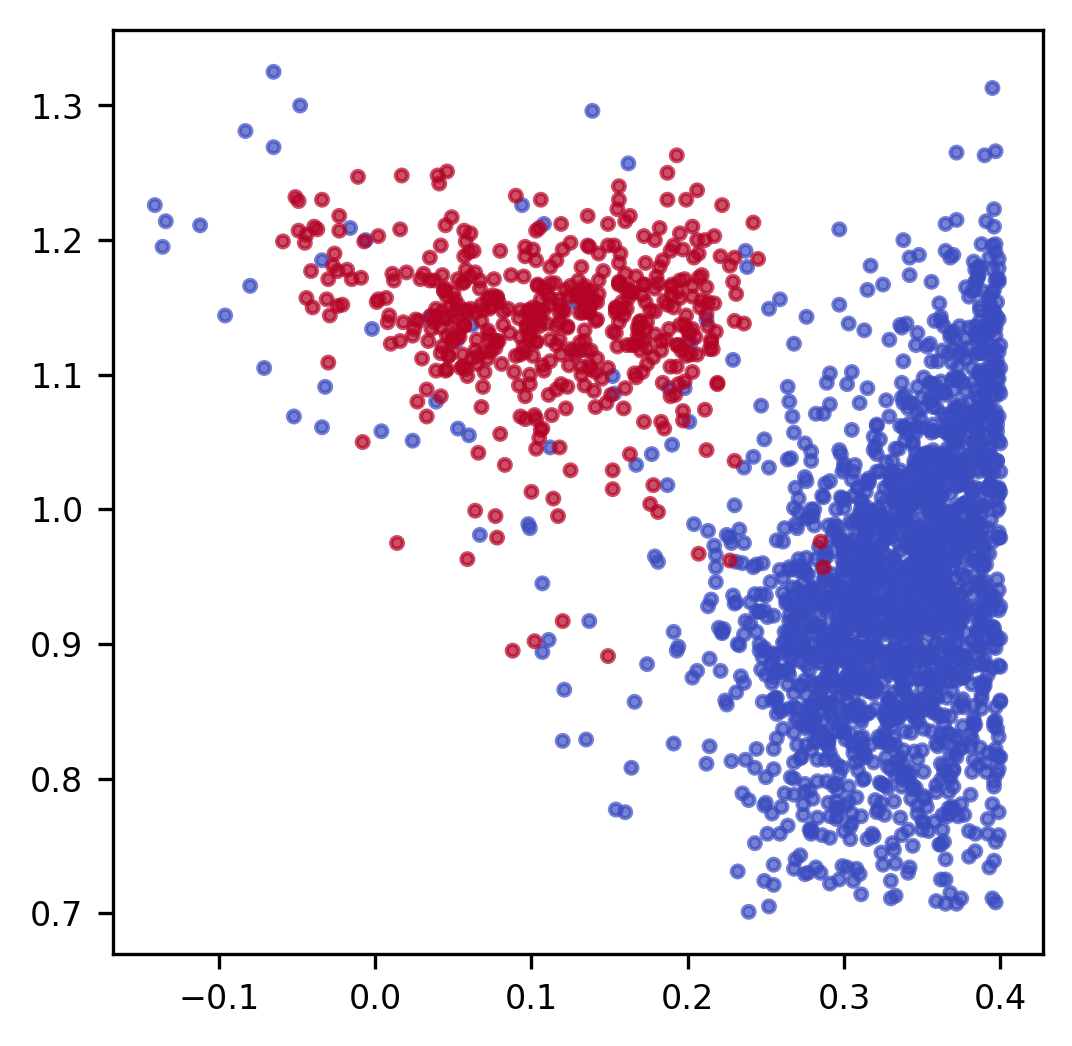

In [58]:
plt.figure(figsize=(4,4))

sc=plt.scatter(df['u-g'], df['g-r'], c=df['RR_Lyrae'], cmap='coolwarm', s=8, alpha=0.7)
plt.show()

### Pregunta
1. ¿Se observan regiones donde las clases parecen separarse?

Sí, se observan regiones donde se separan claramente las clases de las estrellas.

2. A simple vista, ¿esperarías que un árbol de decisión funcione razonablemente bien?

El árbol de decisión funcionaría relativamente bien ya que las clases se encuentran bien separadas, por lo que los cortes de decisión son relativamente claros.

#### Separe los datos en entrenamiento y prueba

In [59]:
X = df[["u-g", "g-r", "r-i", "i-z"]]
y = df["RR_Lyrae"]

In [60]:
#complete la celda
X_train, X_test, y_train, y_test =train_test_split(X,y,test_size=0.3, random_state=42, stratify=y)

In [61]:
X_train.shape

(1738, 4)

### Antes de continuar

Las clases en este problema no están perfectamente balanceadas.

Piense en la forma en que podríamos separar los datos en entrenamiento y prueba, y responda:

1. ¿Qué problema podría ocurrir si hacemos la partición de manera completamente aleatoria, sin preocuparnos por la proporción de clases?
2. ¿Por qué eso podría afectar la evaluación del modelo?
3. ¿Qué tipo de precaución cree que sería razonable tomar al construir los conjuntos de entrenamiento y prueba en este caso?

#### Respuestas:

1.  **¿Qué problema podría ocurrir si hacemos la partición de manera completamente aleatoria, sin preocuparnos por la proporción de clases?**
    *   Si las clases están desbalanceadas, una partición completamente aleatoria podría resultar en que algunos conjuntos (especialmente el de prueba) contengan muy pocas o ninguna muestra de la clase minoritaria. Esto podría llevar a que el modelo no aprenda a reconocer la clase minoritaria o a que su evaluación sea poco fiable.

2.  **¿Por qué eso podría afectar la evaluación del modelo?**
    *   Si el conjunto de prueba tiene pocas o ninguna muestra de la clase minoritaria, métricas como el recall o la precisión para esa clase serían engañosas o incluso imposibles de calcular. Esto impediría una evaluación precisa del rendimiento del modelo en la clase de interés, lo cual es crucial en problemas con datos desbalanceados.

3.  **¿Qué tipo de precaución cree que sería razonable tomar al construir los conjuntos de entrenamiento y prueba en este caso?**
    *   Sería razonable utilizar un muestreo estratificado (`stratified sampling`). Esto garantiza que los conjuntos de entrenamiento y prueba mantengan la misma proporción de clases que el conjunto de datos original. De esta forma, cada conjunto tendrá una representación adecuada de ambas clases, lo que permitirá un entrenamiento y una evaluación más robustos y realistas.

#### Ahora entrenaremos un árbol de decisión (modelo base)

In [62]:
model_tree = DecisionTreeClassifier(random_state=42)
model_tree.fit(X_train, y_train)
#entrene el modelo y genere las predicciones
y_pred=model_tree.predict(X_test)


#### Visualicemos el árbol

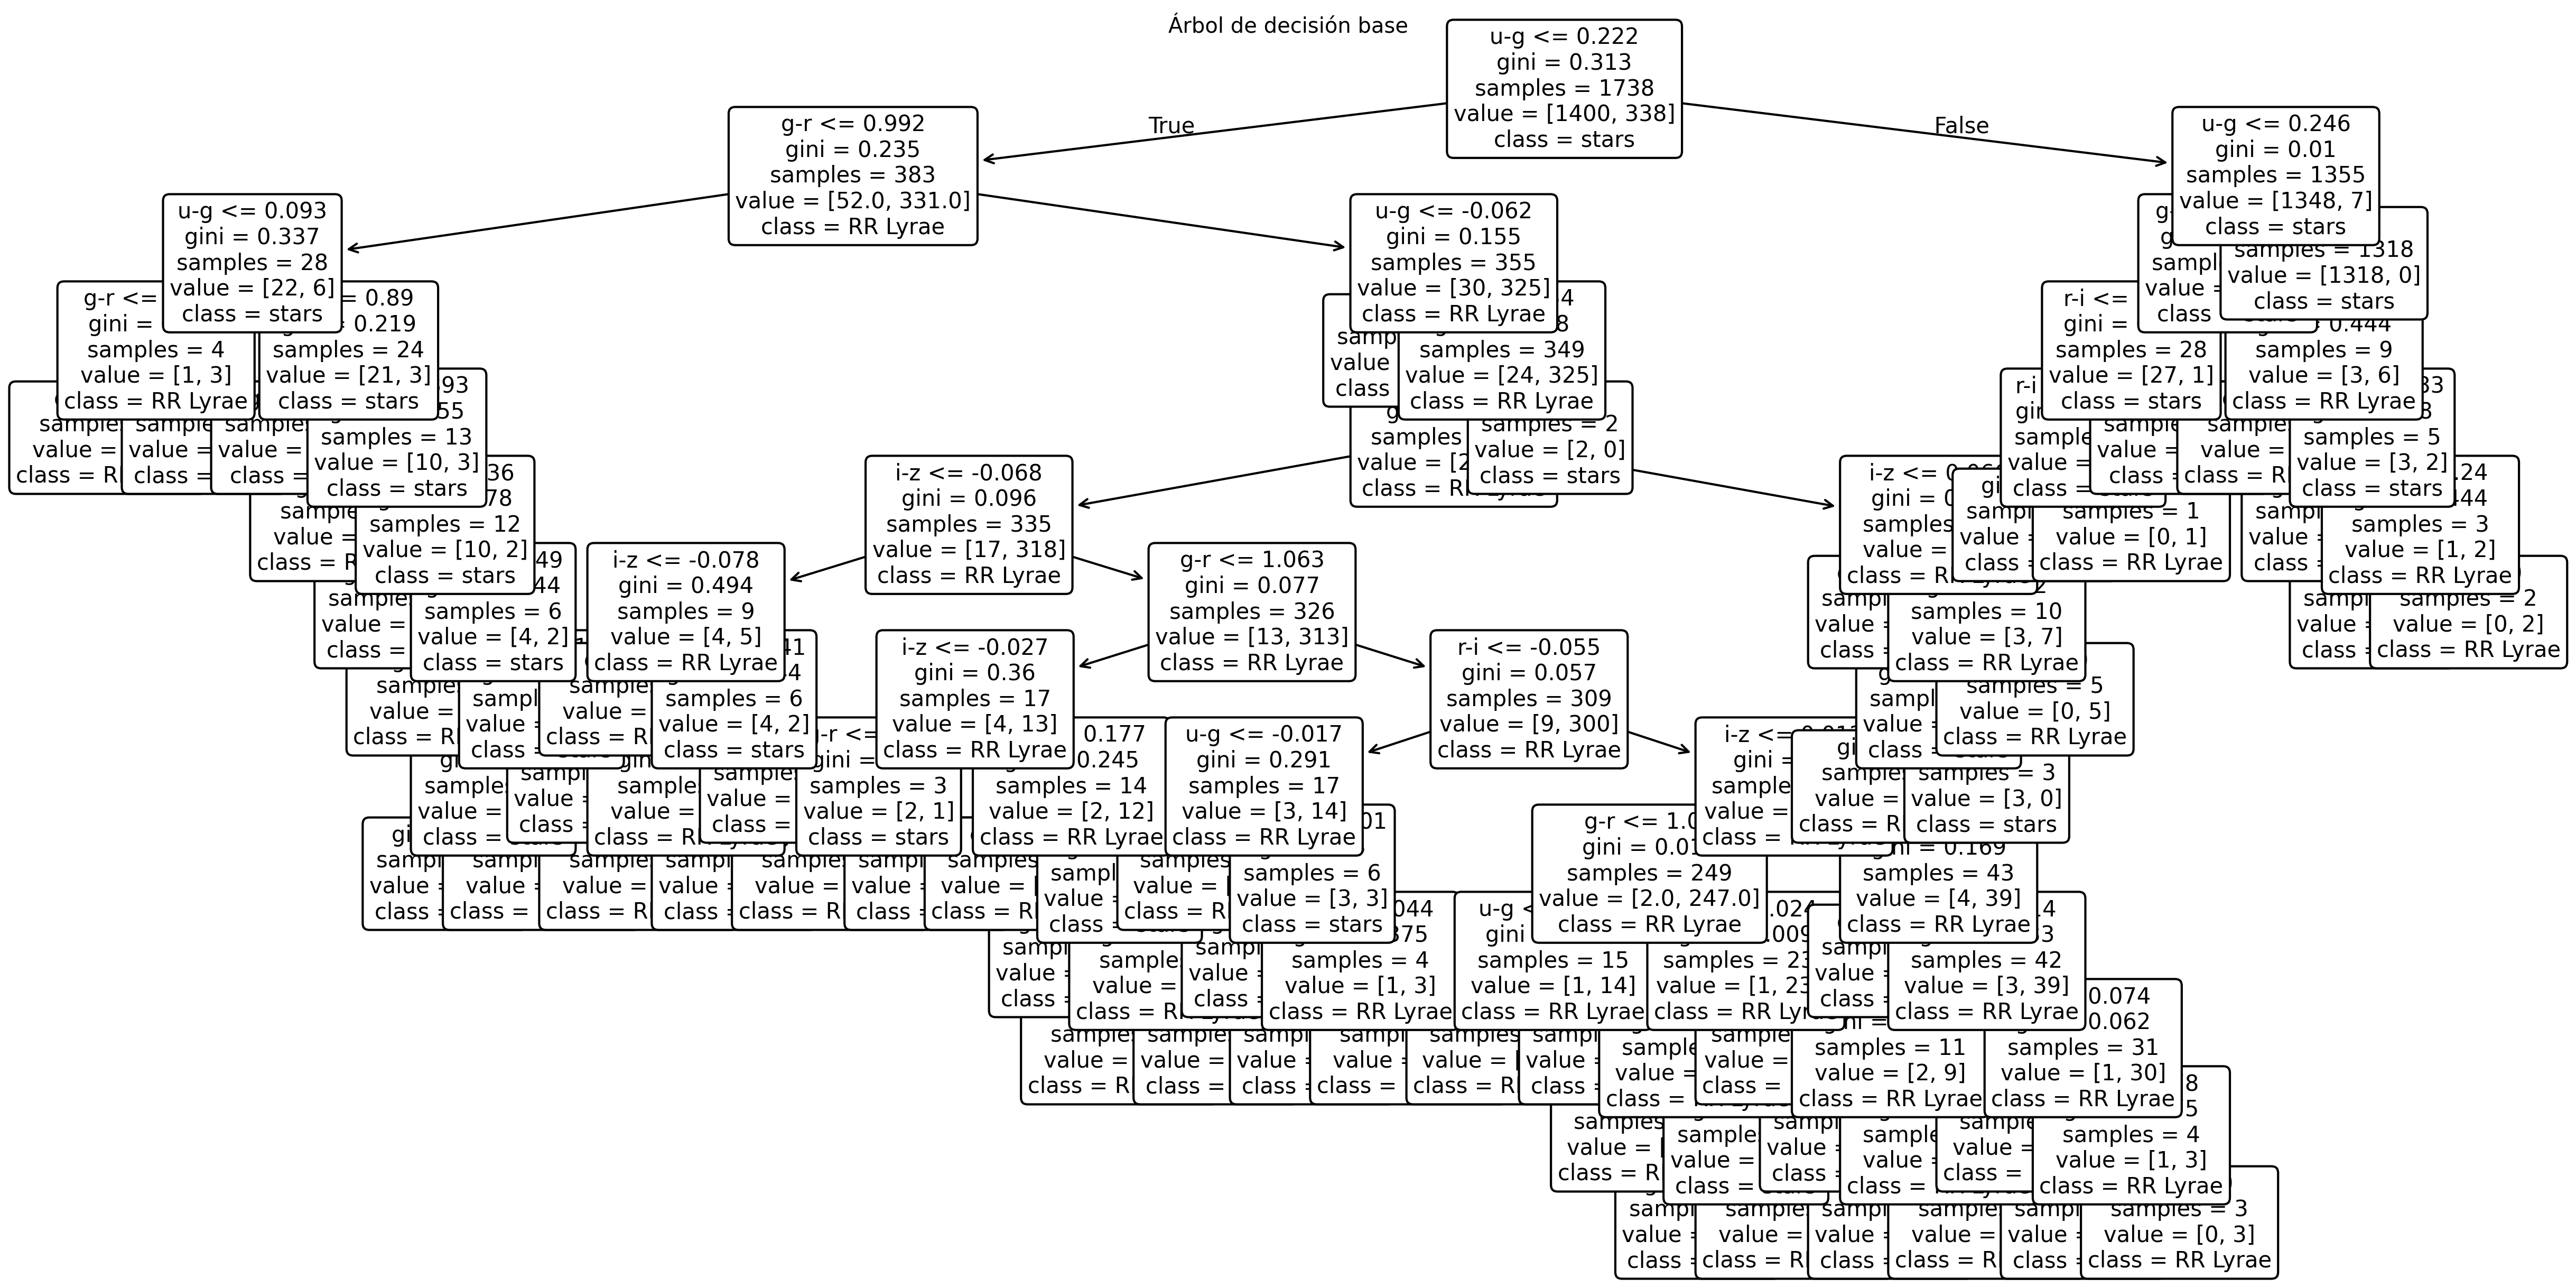

In [63]:
plt.figure(figsize=(20,10))

plot_tree(
    model_tree,
    feature_names=X.columns,
    class_names=["stars", "RR Lyrae"],
    filled=False,
    rounded=True,
    #max_depth=3,
    fontsize=10
)

plt.title("Árbol de decisión base")
plt.show()

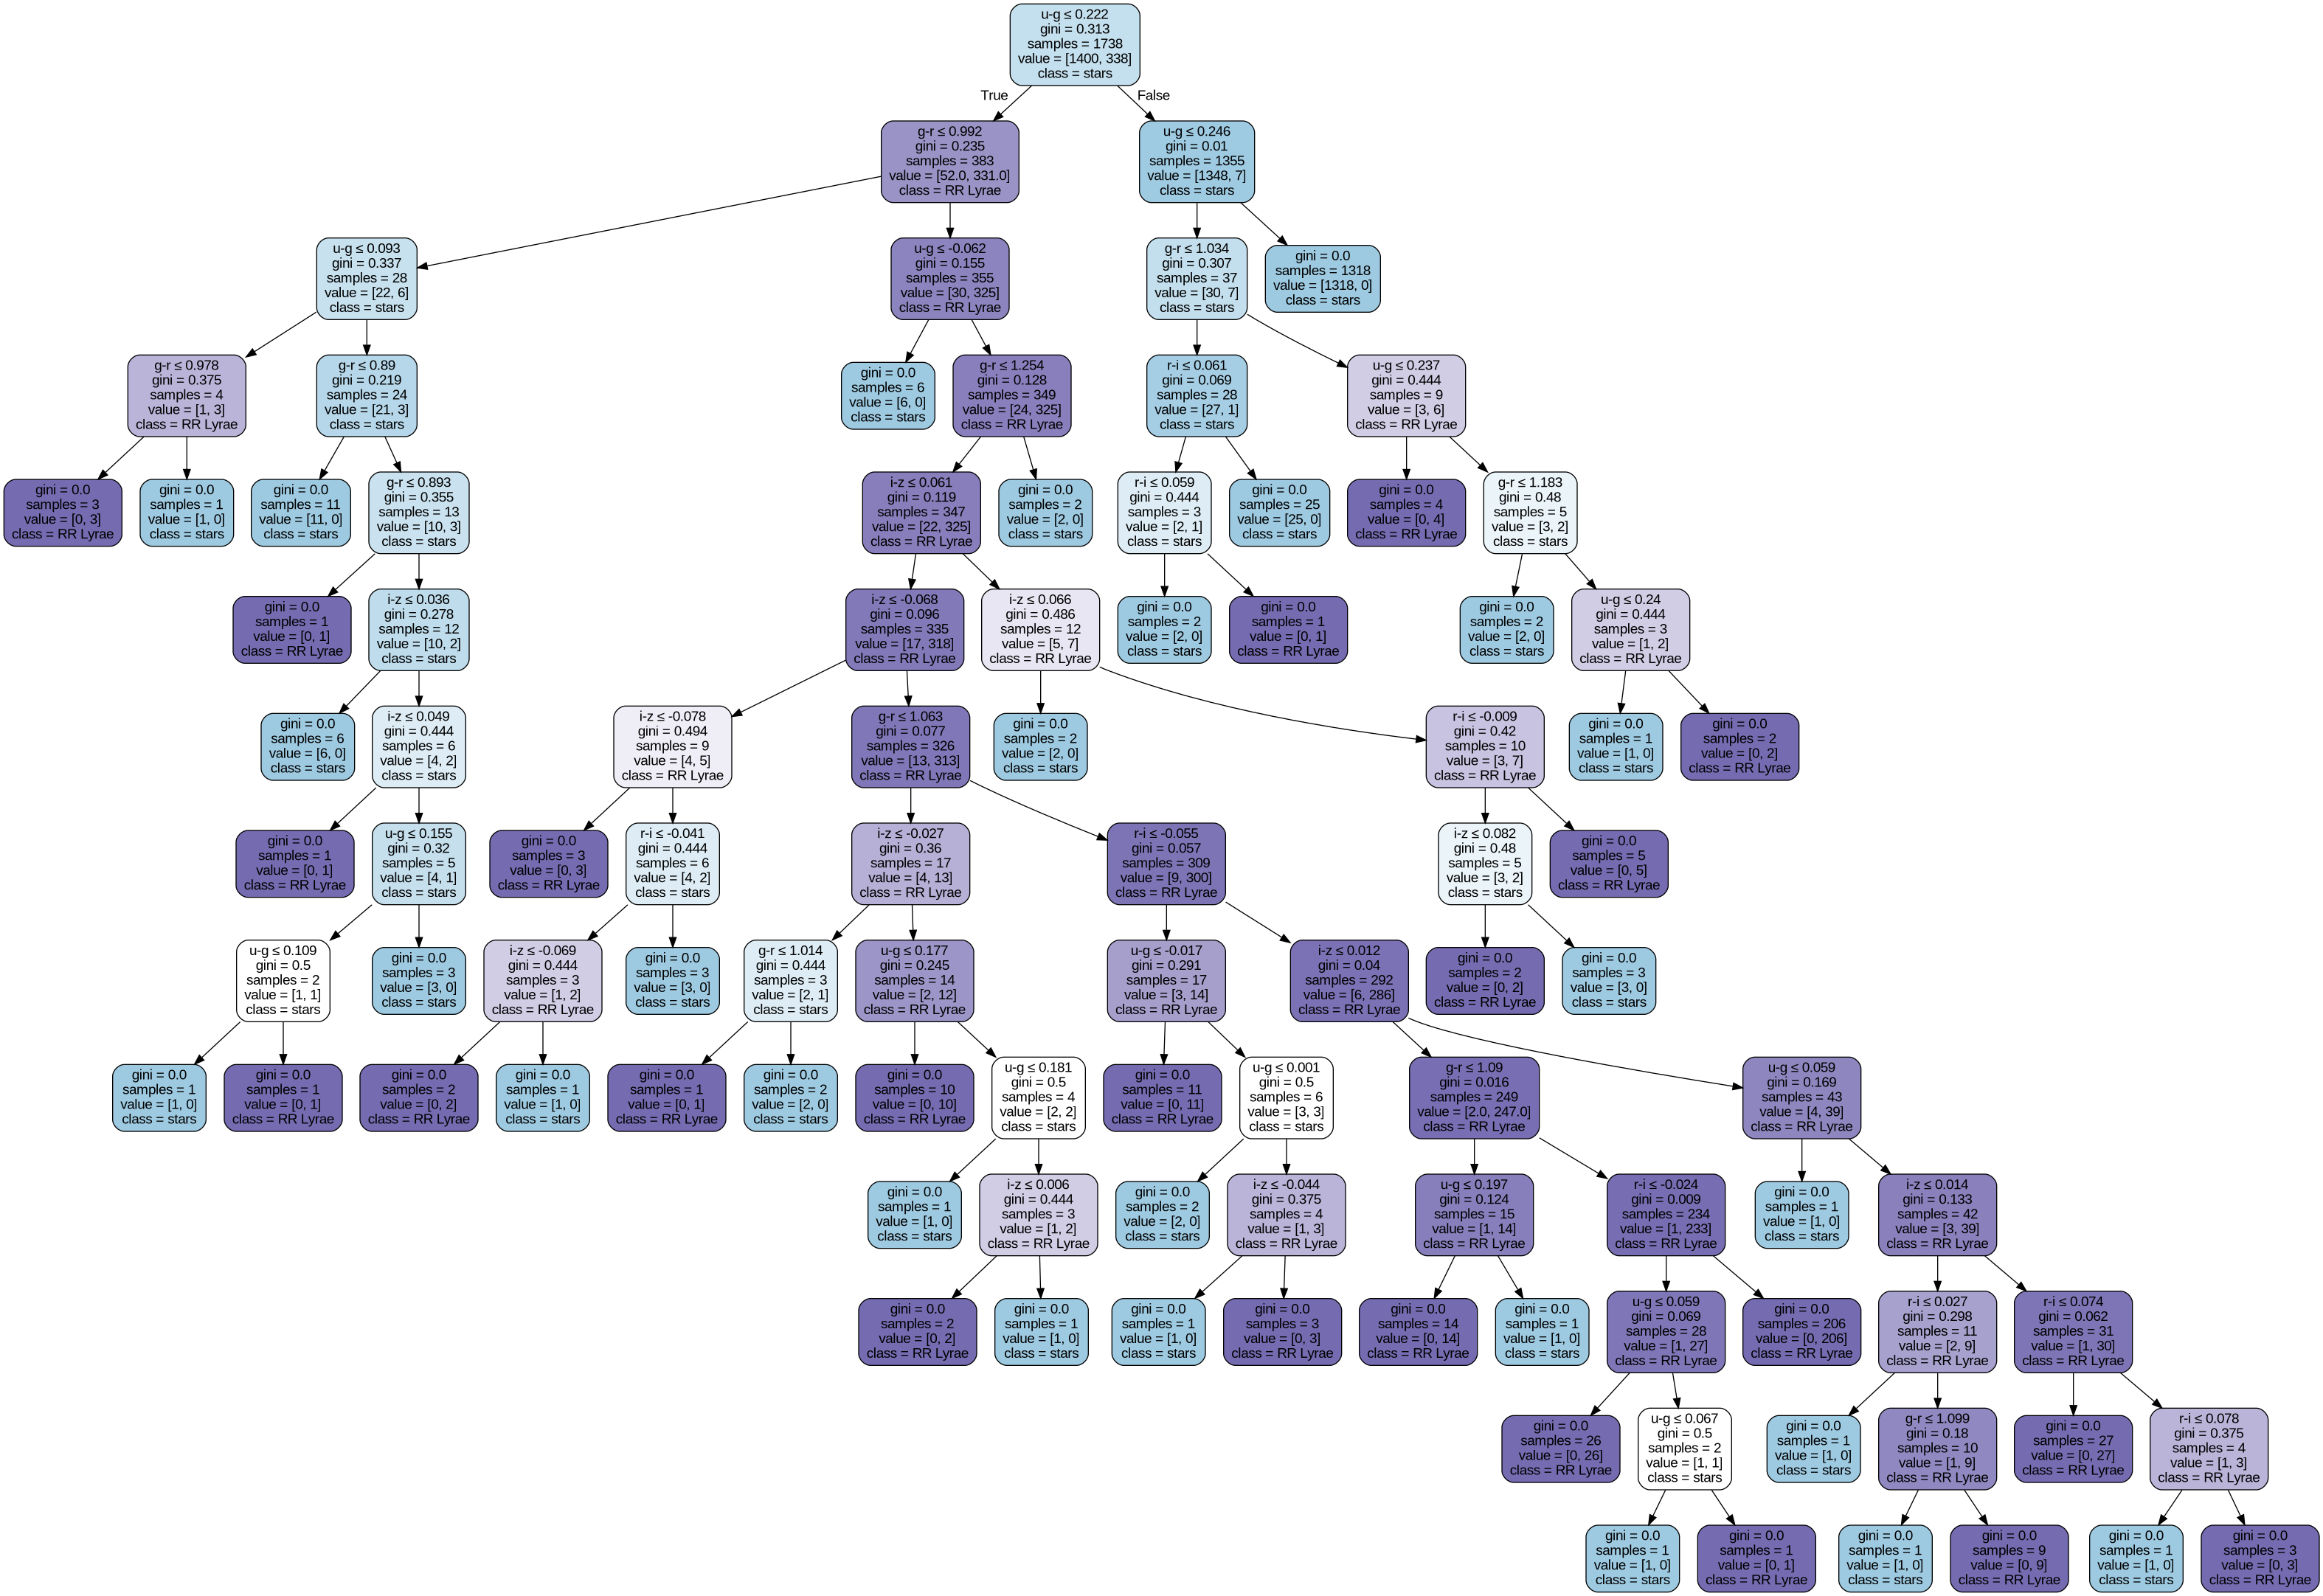

In [64]:
# Recordatorio: Las características siempre se permutan aleatoriamente en cada división.
# Por lo tanto, la mejor división encontrada puede variar, incluso con los mismos datos
# de entrenamiento y max_features=n_features, si la mejora del criterio es idéntica
# para varias divisiones enumeradas durante la búsqueda de la mejor división.
# Para obtener un comportamiento determinista durante el ajuste, random_state debe estar fijo.

dot_data = StringIO()

export_graphviz(
    model_tree,
    out_file=dot_data,
    feature_names=['u-g', 'g-r', 'r-i', 'i-z'],
    class_names=['stars', 'RR Lyrae'],
    filled=True,
    rounded=True,
    special_characters=True
)

graph = pydotplus.graph_from_dot_data(dot_data.getvalue().replace("\n", ""))
nodes = graph.get_node_list()

for node in nodes:
    if node.get_label() and 'value = [' in node.get_label():

        values = [float(ii) for ii in node.get_label().split('value = [')[1].split(']')[0].split(',')]
        values = [int(255 * v / sum(values)) for v in values]

        if values[0] > values[1]:
            alpha = int(values[0] - values[1])
            alpha = '{:02x}'.format(alpha)
            color = '#9ecae1' + str(alpha)   # turquesa
        else:
            alpha = int(values[1] - values[0])
            alpha = '{:02x}'.format(alpha)
            color = '#756bb1' + str(alpha)   # magenta

        node.set_fillcolor(color)

Image(graph.create_png())

### Preguntas

Observe la estructura del árbol y responda brevemente:

1. ¿El árbol parece muy simple o bastante complejo? Justifique a partir del número de niveles o divisiones.

Parece un árbol complejo. Tiene muchas divisiones y niveles de profundidad, intentando llegar a purezas de cero, o sea un índice de Gini igual a cero, llegando a separar muestras muy pequeñas.

2. ¿Qué desventaja podría tener un árbol demasiado grande en un problema como este?

Al ser tan pronfundo y grande el árbol, el modelo termina memorizando el set de entrenamiento en lugar de aprender un patrón fotométrico general en este caso de estrellas. Esto termina dando un sobreajuste en el modelo (overfitting).

#### Miremos las métricas accuracy para set de entrenamiento y prueba

In [65]:
print(metrics.accuracy_score(y_train, model_tree.predict(X_train))) #train score

print(metrics.accuracy_score(y_test, model_tree.predict(X_test))) #test score

1.0
0.978523489932886


#### Otras métricas

In [66]:
print("Precision:", metrics.precision_score(y_test, y_pred))
print("Recall   :", metrics.recall_score(y_test, y_pred))
print("F1-score :", metrics.f1_score(y_test, y_pred))

Precision: 0.951048951048951
Recall   : 0.9379310344827586
F1-score : 0.9444444444444444


In [67]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[593,   7],
       [  9, 136]])

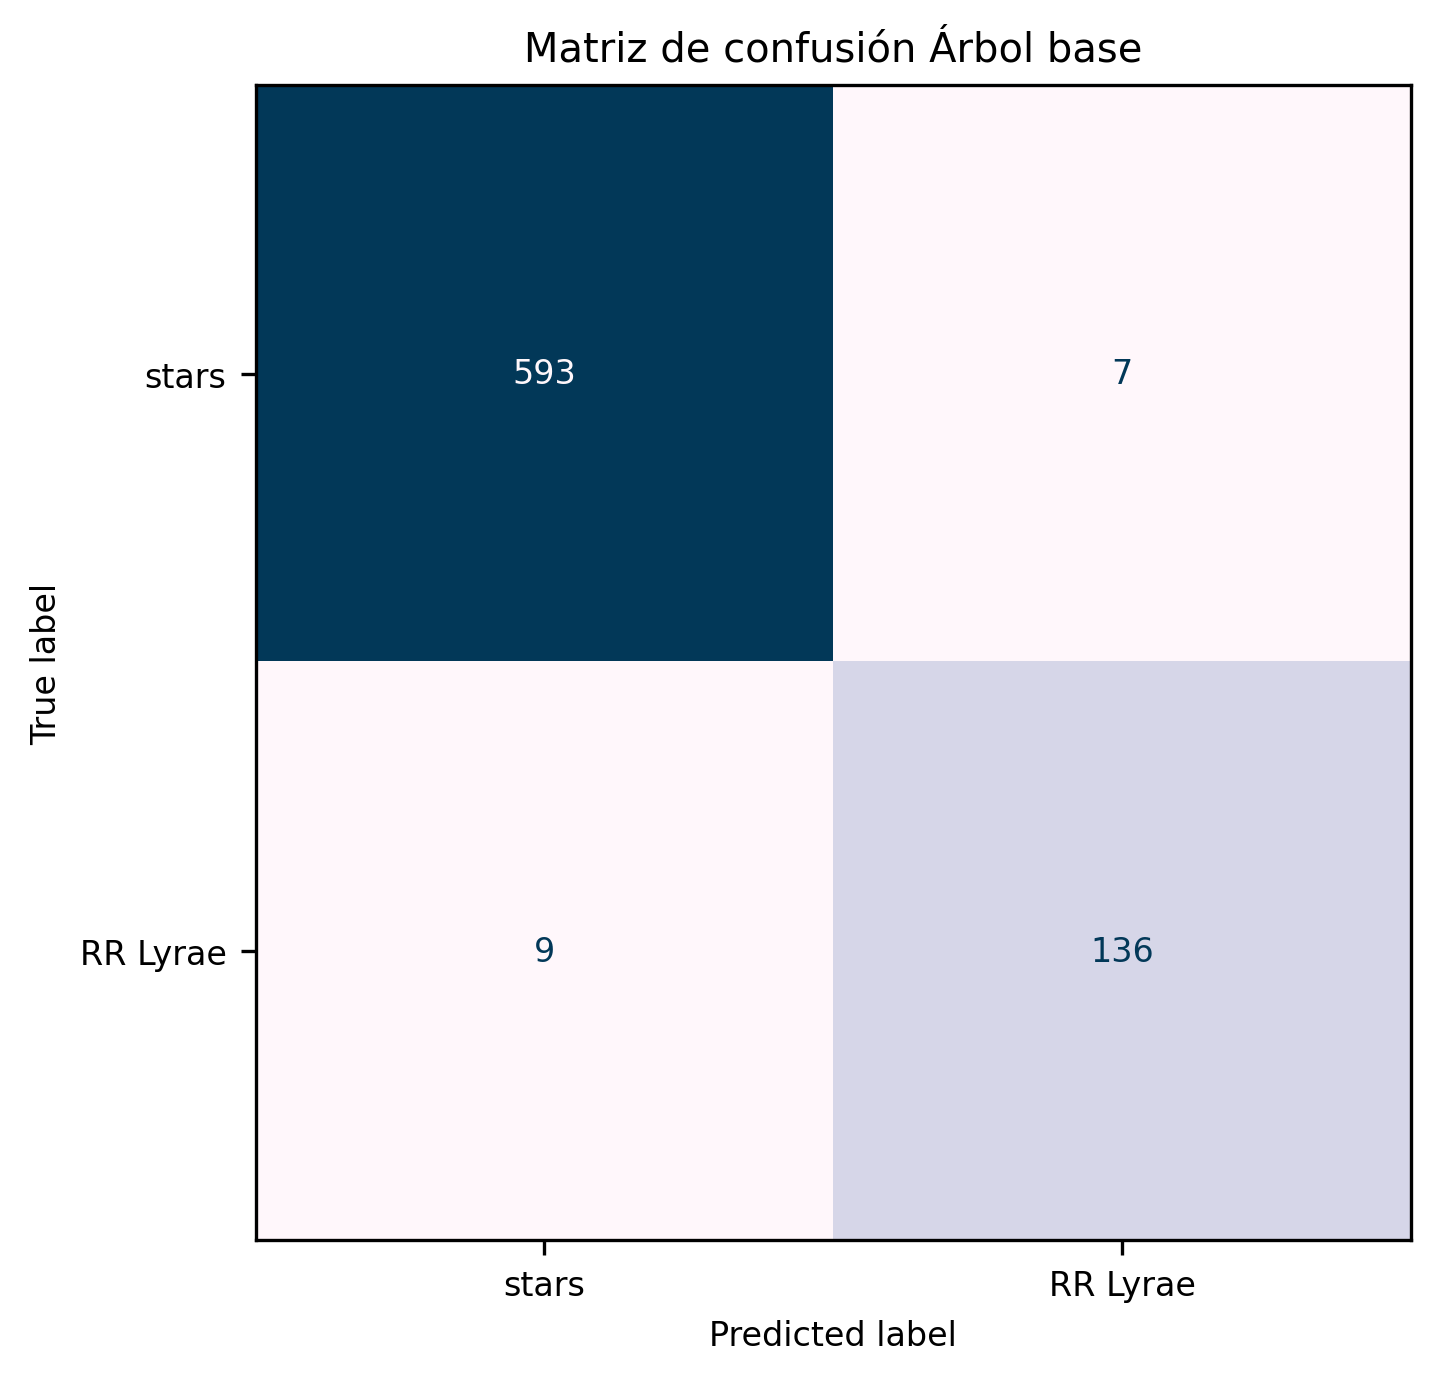

In [68]:
fig, ax = plt.subplots(figsize=(5,5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["stars", "RR Lyrae"])
disp.plot(cmap="PuBu", ax=ax, colorbar=False)

plt.title("Matriz de confusión Árbol base")
plt.show()

#### A partir de la matriz de confusión obtenida:
1.  Identifique los valores de:
   - verdaderos positivos (TP): 136
   - verdaderos negativos (TN): 593
   - falsos positivos (FP): 7
   - falsos negativos (FN): 9

   Clase positiva: RR Lyrae, Clase negativa: stars

2. Calcule las métricas "a mano"

Accuracy: TP+TN/TP+TN+FP+FN = 0.9785 = 97.85 %

Precision: TP/TP+FP = 0.9510 = 95.10 %

Recall: TP/TP+FN = 0.9379 = 93.79 %

F1 score: 2 * (Precision + Recall)/(Precision + Recall) = 0.9444 = 94.44 %





### Preguntas
1. Explique con sus palabras qué significa, en este problema:
   - un falso positivo: El modelo predijo que una estrella como RR Lyrae, pero en realidad no lo era, sino que era de la clase negativa 'stars'

   - un falso negativo: El modelo predijo que una estrella no era RR Lyrae, o sea 'stars' (otra estrella), pero en realidad si era RR Lyrae.

2. Si el objetivo científico fuera encontrar la mayor cantidad posible de RR Lyrae, ¿qué tipo de error preocuparía más?

Habría que preocuparse por lo falsos negativos, debido a que queremos abarcar la mayor cantidad de posibles estrellas RR Lyrae, por lo que queremos maximizar el recall, minimizando los falsos negativos.

3. Si el objetivo fuera construir una muestra final más limpia, ¿qué tipo de error preocuparía más?
Habría que preocuparse por los falsos positivos. Queremos 'ensuciar' lo menos posible el catálogo con estrellas no que son RR Lyrae, por lo que queremos maximizar la Pureza.

#### Todo parece funcionar bien, pero sólo hicimos un split. Necesitamos que el resultados sea robusto. Para esto, implementaremos Cross-validation usando [k-fold](https://scikit--learn-org.translate.goog/stable/modules/generated/sklearn.model_selection.KFold.html?_x_tr_sl=en&_x_tr_tl=es&_x_tr_hl=es&_x_tr_pto=tc)

In [69]:
# Esta es la versión estándar. Importante: no baraja los datos, por lo que si tus
# ejemplos positivos están todos al principio o al final, podría llevar a resultados
# desastrosos.

cv1 = KFold(n_splits = 5)

#Esta es la versión 2: se ha añadido el barajado (¡recomendado!)

cv2 = KFold(shuffle = True, n_splits = 5, random_state=5)

# LA ESTRATIFICACIÓN asegura que las distribuciones de clases en cada división se
# asemejen a las del conjunto de datos completo.

cv3 = StratifiedKFold(shuffle = True, n_splits = 5, random_state=5)


### Efecto de la estratificación: veamos el conteo de clases en cada conjunto de divisiones.

In [70]:
cv1.split(X, y)

<generator object _BaseKFold.split at 0x7d620f3a3450>

In [71]:
for train, test in cv1.split(X, y):
...     print('train -  {}   |   test -  {}'.format(
...         np.bincount(y.loc[train]), np.bincount(y.loc[test])))

train -  [1503  483]   |   test -  [497]
train -  [1503  483]   |   test -  [497]
train -  [1503  483]   |   test -  [497]
train -  [1504  483]   |   test -  [496]
train -  [1987]   |   test -  [ 13 483]


In [72]:
for train, test in cv2.split(X, y):
...     print('train -  {}   |   test -  {}'.format(
...         np.bincount(y.loc[train]), np.bincount(y.loc[test])))

train -  [1600  386]   |   test -  [400  97]
train -  [1610  376]   |   test -  [390 107]
train -  [1587  399]   |   test -  [413  84]
train -  [1599  388]   |   test -  [401  95]
train -  [1604  383]   |   test -  [396 100]


In [73]:
for train, test in cv3.split(X, y):
...     print('train -  {}   |   test -  {}'.format(
...         np.bincount(y.loc[train]), np.bincount(y.loc[test])))

train -  [1600  386]   |   test -  [400  97]
train -  [1600  386]   |   test -  [400  97]
train -  [1600  386]   |   test -  [400  97]
train -  [1600  387]   |   test -  [400  96]
train -  [1600  387]   |   test -  [400  96]


### La función [`cross_validate`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_validate.html#sklearn.model_selection.cross_validate) proporciona los puntajes (especificados por el parámetro de evaluación elegido), en forma de diccionario.

In [74]:
scores1 = cross_validate(DecisionTreeClassifier(), X, y, cv = cv1, scoring = 'accuracy')

scores2 = cross_validate(DecisionTreeClassifier(), X, y, cv = cv2, scoring = 'accuracy')

scores3 = cross_validate(DecisionTreeClassifier(), X, y, cv = cv3, scoring = 'accuracy')

In [75]:
scores3

{'fit_time': array([0.01171637, 0.00878239, 0.0096755 , 0.0100913 , 0.00936627]),
 'score_time': array([0.00514293, 0.00368428, 0.0040338 , 0.00390148, 0.00408173]),
 'test_score': array([0.98189135, 0.96579477, 0.96579477, 0.97580645, 0.95564516])}

Solo nos interesa el 'test_score'

#### Calculamos el promedio y $\sigma$

In [76]:
print("{:.3f}".format(scores1['test_score'].mean()), "{:.3f}".format(scores1['test_score'].std()))

0.786 0.380


In [77]:
print("{:.3f}".format(scores2['test_score'].mean()), "{:.3f}".format(scores2['test_score'].std()))

0.965 0.011


In [78]:
print("{:.3f}".format(scores3['test_score'].mean()), "{:.3f}".format(scores3['test_score'].std()))

0.969 0.009


La validación cruzada sin barajar (`cv1`) produce un resultado muy inestable, con una desviación estándar extremadamente alta. Esto ocurre porque los datos están ordenados por clase, de modo que algunos folds no representan bien el problema completo.

Al activar el barajado (`cv2`), el rendimiento mejora drásticamente y la dispersión disminuye. Sin embargo, el método que resulta más apropiado para este problema es `StratifiedKFold` (`cv3`), ya que además de mezclar los datos, conserva aproximadamente la proporción de clases en cada fold.

En problemas de clasificación desbalanceada, esta última estrategia suele ser la más recomendable.

In [79]:
scores1 = cross_validate(DecisionTreeClassifier(random_state=1), X,y, cv = cv1, scoring = 'recall')

scores2 = cross_validate(DecisionTreeClassifier(random_state=1), X,y, cv = cv2, scoring = 'recall')

scores3 = cross_validate(DecisionTreeClassifier(random_state=1), X,y, cv = cv3, scoring = 'recall')

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricW

In [80]:
print("{:.3f}".format(scores1['test_score'].mean()), "{:.3f}".format(scores1['test_score'].std()))
print("{:.3f}".format(scores2['test_score'].mean()), "{:.3f}".format(scores2['test_score'].std()))
print("{:.3f}".format(scores3['test_score'].mean()), "{:.3f}".format(scores3['test_score'].std()))

nan nan
0.903 0.016
0.925 0.019


### ¿Por qué aparece este warning?

En algunos folds generados por `KFold` sin barajado, el conjunto de prueba contiene solo ejemplos de una clase. En ese caso, el recall de la clase positiva (RR Lyrae) no puede calcularse, porque no hay positivos reales en ese fold.

Esto muestra que una estrategia de partición inadecuada puede hacer que la evaluación sea inestable, engañosa o incluso inválida.

#### También extraeremos los train scores, que nos servirán cuando estemos diagnosticando el modelo a través de bias vs variance.¶

In [81]:
scores1 = cross_validate(DecisionTreeClassifier(), X,y, cv = cv1, scoring = 'recall', \
                         return_train_score = True)

scores2 = cross_validate(DecisionTreeClassifier(), X,y, cv = cv2, scoring = 'recall', \
                         return_train_score = True)

scores3 = cross_validate(DecisionTreeClassifier(), X,y, cv = cv3, scoring = 'recall',
                         return_train_score = True)

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricW

In [82]:
print("{:.3f}".format(scores1['test_score'].mean()), "{:.3f}".format(scores1['train_score'].mean()))
print("{:.3f}".format(scores2['test_score'].mean()), "{:.3f}".format(scores2['train_score'].mean()))
print("{:.3f}".format(scores3['test_score'].mean()), "{:.3f}".format(scores3['train_score'].mean()))

nan nan
0.910 1.000
0.925 1.000


### La función  `cross_validate` es útil para calcular el puntaje, pero no produce etiquetas predichas.

#### Estas pueden obtenerse utilizando la función [`cross_val_predict`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_predict.html), que guarda las predicciones para cada uno de los k-folds de prueba y las compila juntas.


In [83]:
model1 = DecisionTreeClassifier(random_state = 3)

y_cv3 = cross_val_predict(model1, X,y, cv = cv3)
# Estas son las predicciones,
# y son independientes del parámetro de evaluación

In [84]:
metrics.confusion_matrix(targets,y_cv3)

array([[1955,   45],
       [  33,  450]])

### Sin embargo, las cosas pueden cambiar si uso un esquema de validación cruzada diferente:

In [85]:
model2 = DecisionTreeClassifier(random_state = 3)

y_cv2 = cross_val_predict(model2, X,y, cv = cv2)

In [86]:
np.sum(y_cv3-y_cv2)

np.int64(10)

In [87]:
np.sum(y_cv2)

np.int64(485)

In [88]:
np.sum(y_cv3 != y_cv2) #comparando las predicciones

np.int64(52)

In [89]:
metrics.confusion_matrix(targets,y_cv2)

array([[1955,   45],
       [  43,  440]])

In [90]:
metrics.confusion_matrix(targets,y_cv3)

array([[1955,   45],
       [  33,  450]])

In [91]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, title, X, y, ylim=None, cv=5,
                        n_jobs=-1, train_sizes=np.linspace(0.2, 1.0, 5), scoring = 'accuracy'):
    """
    Generate a simple plot of the test and training learning curve.

    Parameters
    ----------
    estimator : object type that implements the "fit" and "predict" methods
        An object of that type which is cloned for each validation.

    title : string
        Title for the chart.

    X : array-like, shape (n_samples, n_features)
        Training vector, where n_samples is the number of samples and
        n_features is the number of features.

    y : array-like, shape (n_samples) or (n_samples, n_features), optional
        Target relative to X for classification or regression;
        None for unsupervised learning.

    ylim : tuple, shape (ymin, ymax), optional
        Defines minimum and maximum yvalues plotted.

    cv : int, cross-validation generator or an iterable, optional
        Determines the cross-validation splitting strategy.
        Possible inputs for cv are:
          - None, to use the default 3-fold cross-validation,
          - integer, to specify the number of folds.
          - :term:`CV splitter`,
          - An iterable yielding (train, test) splits as arrays of indices.

        For integer/None inputs, if ``y`` is binary or multiclass,
        :class:`StratifiedKFold` used. If the estimator is not a classifier
        or if ``y`` is neither binary nor multiclass, :class:`KFold` is used.

        Refer :ref:`User Guide <cross_validation>` for the various
        cross-validators that can be used here.

    n_jobs : int or None, optional (default=None)
        Number of jobs to run in parallel.
        ``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.
        ``-1`` means using all processors. See :term:`Glossary <n_jobs>`
        for more details.

    train_sizes : array-like, shape (n_ticks,), dtype float or int
        Relative or absolute numbers of training examples that will be used to
        generate the learning curve. If the dtype is float, it is regarded as a
        fraction of the maximum size of the training set (that is determined
        by the selected validation method), i.e. it has to be within (0, 1].
        Otherwise it is interpreted as absolute sizes of the training sets.
        Note that for classification the number of samples usually have to
        be big enough to contain at least one sample from each class.
        (default: np.linspace(0.1, 1.0, 5))
    """
    plt.figure(figsize=(10,6))
    plt.title(title)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.xlabel("Training examples")
    plt.ylabel(str(scoring))

    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes, scoring = scoring, shuffle=True, random_state=42)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    plt.grid()

    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r",
             label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g",
             label="Test score from cross-validation")

    plt.legend(loc="best")
    return plt

In [92]:
model = DecisionTreeClassifier(random_state = 5)

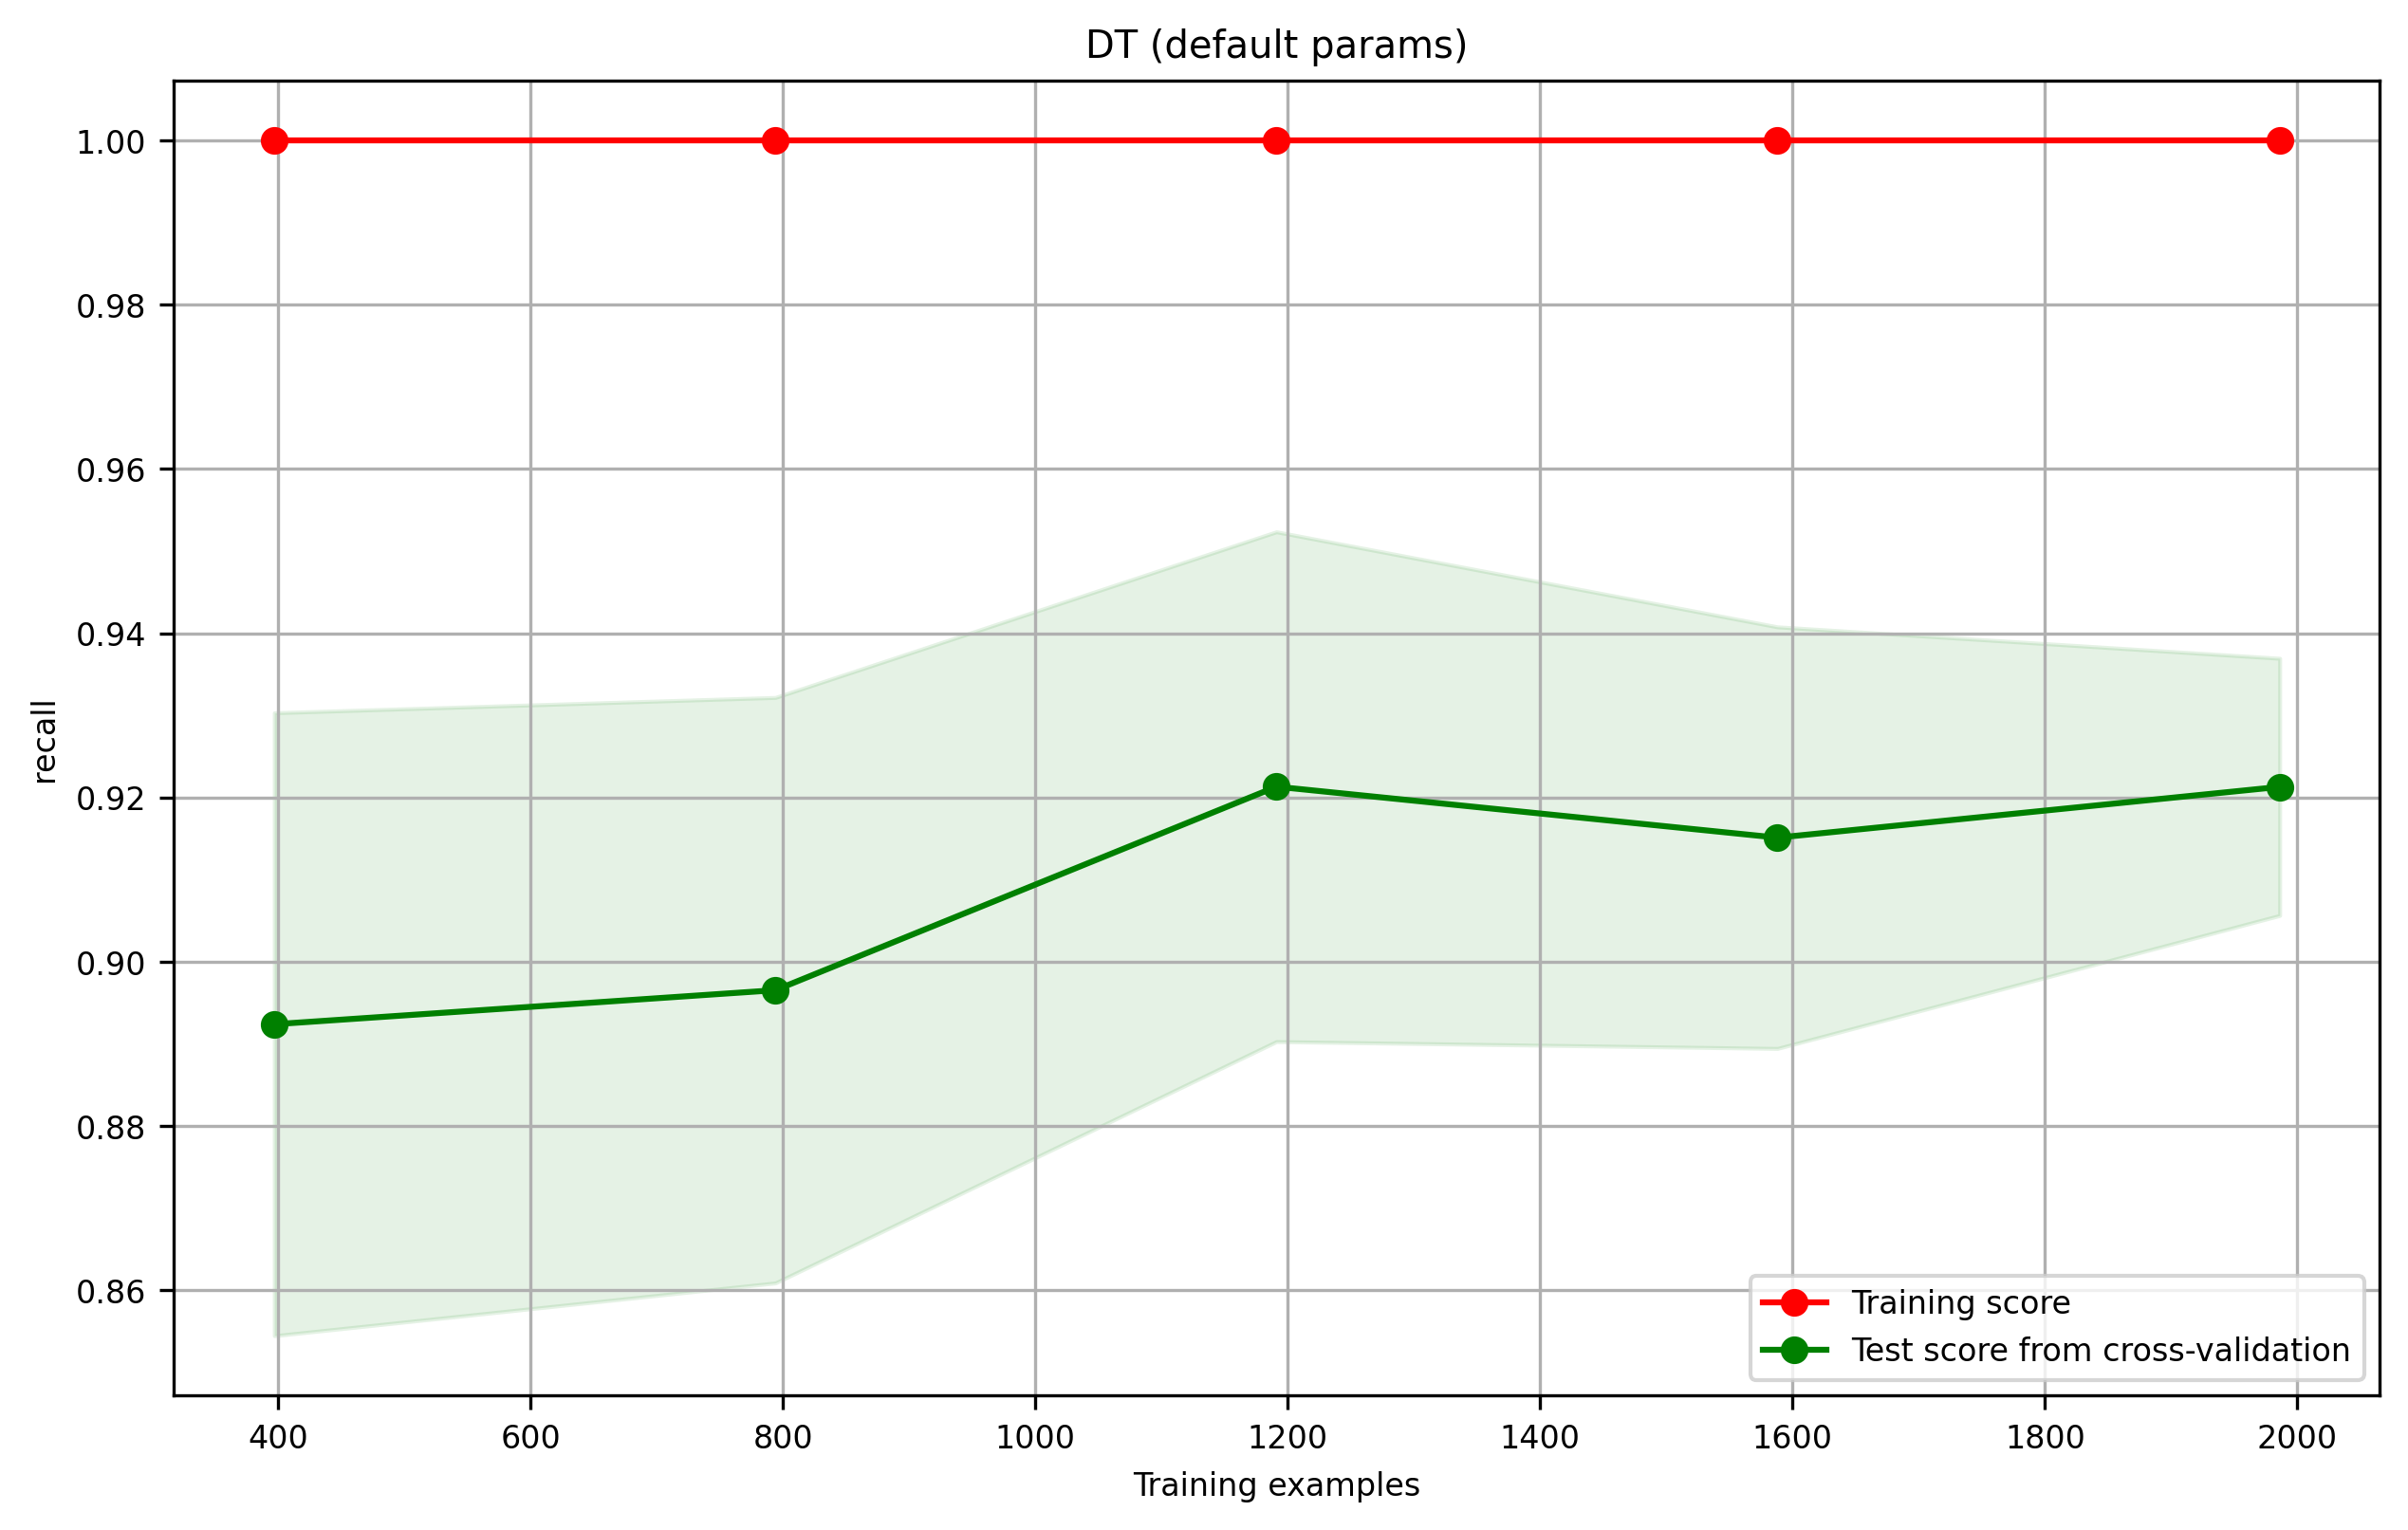

In [93]:
plot_learning_curve(model, 'DT (default params)', X, y,  cv = cv3, scoring = 'recall');

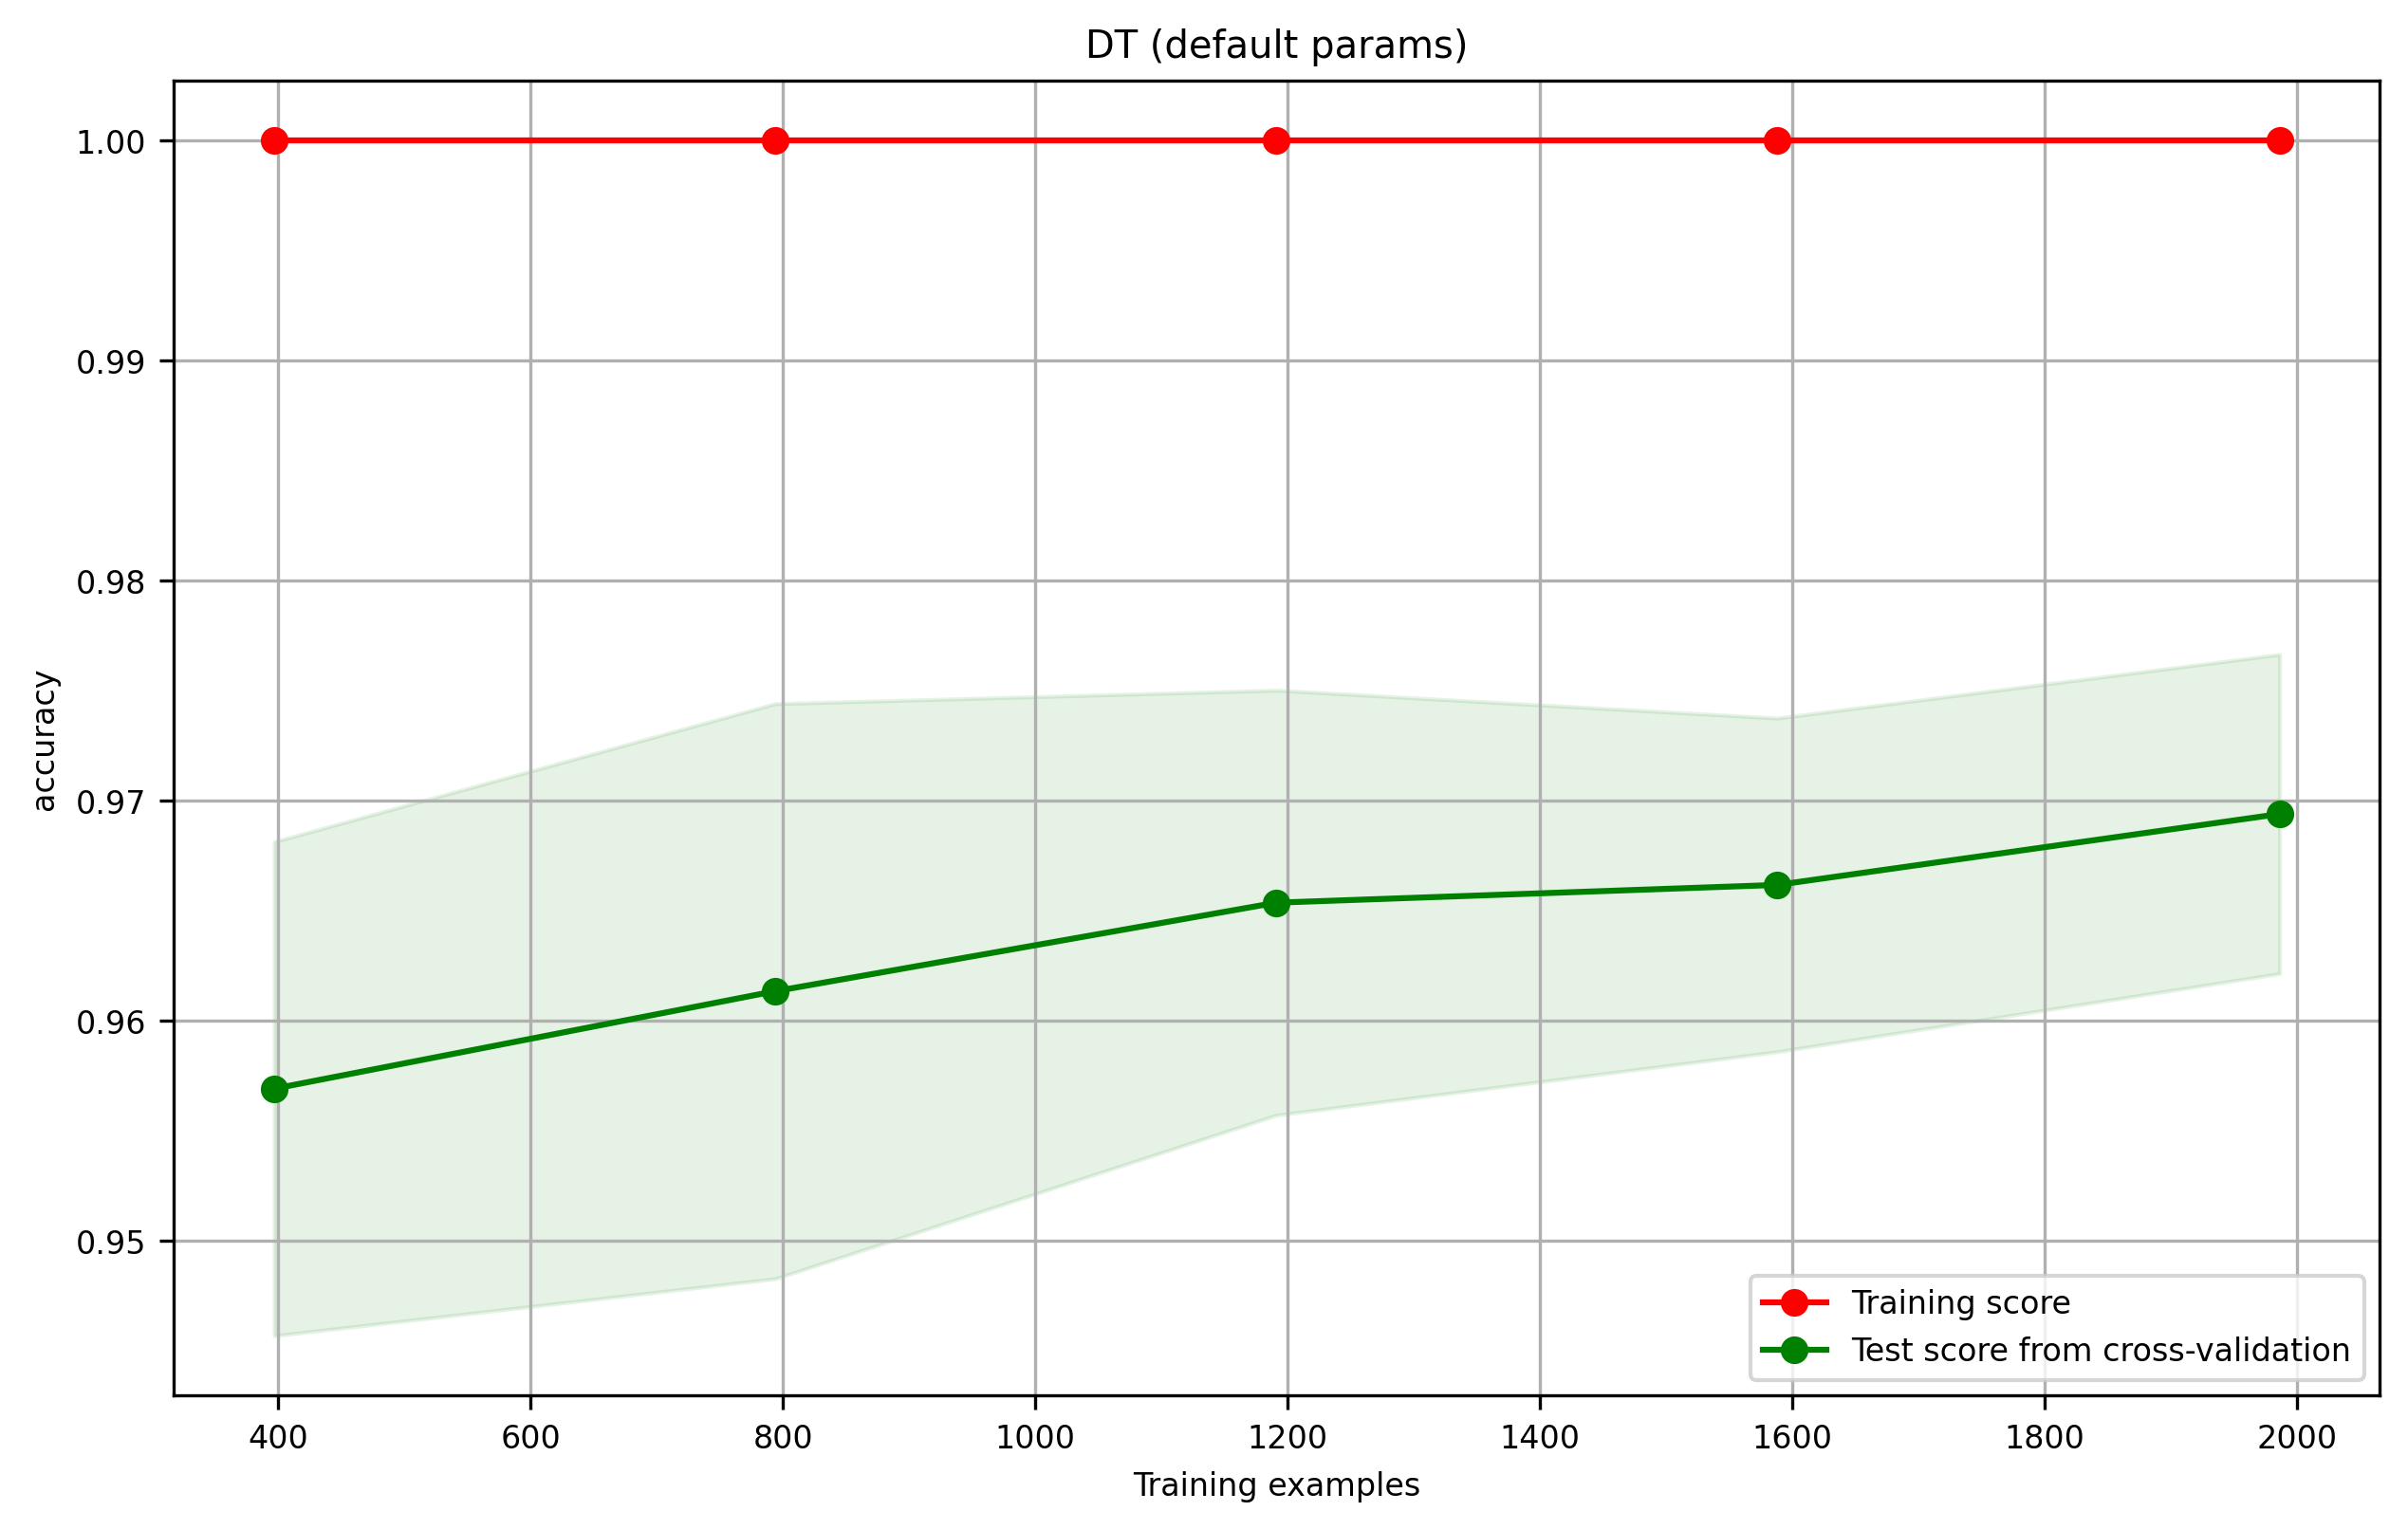

In [94]:
plot_learning_curve(model, 'DT (default params)', X, y,  cv = cv3, scoring = 'accuracy');

### **Preguntas**

Responda brevemente:

1. ¿Existe una brecha entre la curva de entrenamiento y la de validación? ¿Qué sugiere eso?

Sí, la curva de entrenamiento se encuentra constante en 1.0, o sea un accuracy perfecto del 100%, mientras que la curva de validacón  se encuentra en valores menores. Esto muestra un problema de sobreajuste (overfitting), o sea que el modelo memorizó los datos de entrenamiento, pero luego al enfrentarse con con datos nuevos le cuesta generalizar estos.

2. ¿El rendimiento de validación mejora al agregar más ejemplos?

Sí, la curva muestra una tendencia positiva ligera a medida que consideramos mayores training examples, por lo tanto, esto nos lleva a pensar que mayor volumen de datos ayuda al modelo a aprender mejor los patrones de identificación.

3. ¿Hablaría aquí de alto sesgo, alta varianza o sobreajuste moderado? Justifique.

Al hablar observar un overfitting del modelo, estamos en un caso de alta varianza. El sesgo es nulo ya que el modelo acierta todo en el set de entrenamiento, pero su rendimiento decae mucho al ser evaluado con los datos de la validación cruzada. Además el árbol generado es uno sumamente complejo considerando el objetivo del caso.


4. Escriba una conclusión general sobre el comportamiento del árbol base a partir de estas curvas.

El árbol creció demasiado en profundidad y se complejizó demasiado para este problema, por lo que se sobreajustó en el conjunto de entrenamiento. Esto es debido a que no pusimos restricciones sobre la profundidad del árbol, por lo que concluimos que no es un modelo robusto para categorizar y hacer predicciones correctas en un catálogo de estrellas nuevo.



### Desafío: ¿un árbol más simple generaliza mejor?

Entrene ahora un segundo árbol, más restringido que el árbol base. Por ejemplo, puede probar con:

- `max_depth=3`, o
- `min_samples_leaf=10`

Luego compare su rendimiento con el árbol base usando:

- accuracy
- precision
- recall
- F1-score



In [95]:

metricas = ['accuracy', 'precision', 'recall', 'f1']


tree_base = DecisionTreeClassifier(random_state=42)
scores_base = cross_validate(tree_base, X, y, cv=cv3, scoring=metricas)

#(restringido con max_depth=3)
tree_simple = DecisionTreeClassifier(max_depth=3, random_state=42)
scores_simple = cross_validate(tree_simple, X, y, cv=cv3, scoring=metricas)


print("Comparación de modelos (Validación Cruzada CV3)")
for m in metricas:
    print(f"{m.capitalize()}:")
    print(f"  Árbol Base:   {scores_base['test_'+m].mean():.4f}")
    print(f"  Árbol Simple: {scores_simple['test_'+m].mean():.4f}\n")

Comparación de modelos (Validación Cruzada CV3)
Accuracy:
  Árbol Base:   0.9710
  Árbol Simple: 0.9770

Precision:
  Árbol Base:   0.9203
  Árbol Simple: 0.9247

Recall:
  Árbol Base:   0.9316
  Árbol Simple: 0.9606

F1:
  Árbol Base:   0.9259
  Árbol Simple: 0.9421



### Preguntas

A partir de los resultados obtenidos con validación cruzada:

1. ¿Qué ocurrió con el rendimiento al restringir la complejidad del árbol?

El rendimiento en el test de prueba del cross validate mejoró sustancialmente en todas las métricas.

2. ¿El árbol más simple empeoró o mejoró la generalización?

La mejoró. Al poner un límite de profundidad aprendió correctamente las reglas fotométricas y clasificó mejor el set de estrellas de testeo.

3. ¿Qué sugieren estos resultados sobre el árbol base?

Confirman el sobreajuste que generaba este árbol complejo, ya que memorizaba los datos del training set para luego fallar al evaluar correctamente  los datos nuevos.

4. En este problema, ¿parece conveniente usar el árbol sin restricciones?

No. Como ya dijimos el árbol sin restricciones se vuelve sumamente complejo y se sobreajusta el modelo, lo que lo hace menos confiable y preciso para un escenario astronómico real.

5. ¿Qué métrica le parece más importante para decidir entre ambos modelos?

El Recall es una métrica que destaca para este problema, ya que nos interesa encontrar la mayor cantidad de estrellas RR Lyrae sin que se nos escapen candidatas reales. Sin embargo, F1-score es la métrica más completa, ya que equilibra entre Precision y Recall.

## Desafío: comparar con kNN

Hasta ahora trabajamos con árboles de decisión. Ahora comparemos ese enfoque con un clasificador distinto: **k-Nearest Neighbors (kNN)**.

Entrene un modelo kNN y compárelo con el árbol simple usando validación cruzada estratificada. Recuerde que kNN está basado en distancias, por lo que antes de entrenarlo debe escalar las variables.

### Instrucciones

1. Entrene un modelo kNN con `k=5`.
2. Use un `StandardScaler` antes del clasificador.
3. Evalúe el modelo con validación cruzada estratificada usando:
   - accuracy
   - precision
   - recall
   - F1-score
4. Compare sus resultados con los del árbol simple.
5. Luego explore distintos valores de `k` y vea cómo cambian las métricas.

### Preguntas

1. ¿Cómo se compara el rendimiento de kNN con el del árbol simple?

El rendimiento para el caso de k=5 de kNN es ligeramente superior al del árbol simple. Mejora el Recall (subió a 0.9689), por lo que hay un aumento de detección total de estrellas RR Lyrae reales. Además el F1 score se mantiene relativamente cercano (0.9446), por lo que hay un equilibrio, pero sacrifica un valor pequeño de Precision (0.9215 contra 0.9247 c/r al árbol).

2. ¿Qué ocurre cuando `k` es muy pequeño?

El modelo se sobreajusta, o sea, contiene una alta varianza. Al considerar solamente 1 vecino para clasificar, la predicción se vuelve sensible a valores atípicos. Se observa además que las métricas en general decaen todas con respecto a los otros casos.

3. ¿Qué ocurre cuando `k` es muy grande?

Ocurre un subajuste en el modelo, o sea, contiene un alto bias. Al considerar demasiados vecinos (k=50 por ejemplo), la clase mayoritaria (en este caso las estrellas comunes que no son RR Lyrae) comienza a dominar por sobre la clase minoritaria meramente por volumen. Esto hace que la Precision o pureza decaiga significativamente (baja aprox 0.89), y por lo tanto el F1-score también.

4. ¿Qué valor de `k` parece dar el mejor equilibrio entre precision y recall?

El mejor caso de equilibrio es el del valor k=5, ya que es el punto donde se alcanza el mayor valor de F1-score de toda la exploración (recordemos que F1-score es un balance entre Recall y Precision).

5. ¿Qué ventaja podría tener kNN si la frontera entre clases no es rectangular?

Como sabemos los árboles de decisión realizan cortes rectos y paralelos a los ejes para dividir su frontera de decisión. Por otra parte, los modelos de tipo kNN se basan en medir distancias en cualquier dirección y con distintas formas de medición, por lo que puede crear fronteras de decisión curvas e irregulares que se asemejan a distribuciones que no son rectangulares, como es en nuestro caso, donde se adapta mejor a la forma natural de la distribución del color de las estrellas.



In [96]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline

In [97]:
knn = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5))
scores_knn = cross_validate(knn, X, y, cv=cv3, scoring=metricas)

print("Resultados kNN (k=5)")
for m in metricas:
    print(f"{m.capitalize()}: {scores_knn['test_'+m].mean():.4f}")

Resultados kNN (k=5)
Accuracy: 0.9778
Precision: 0.9215
Recall: 0.9689
F1: 0.9446


In [98]:
ks = [1, 3, 5, 15, 30, 50]
for k in ks:
    knn_explore = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k))
    scores_explore = cross_validate(knn_explore, X, y, cv=cv3, scoring=metricas)
    f1 = scores_explore['test_f1'].mean()
    recall = scores_explore['test_recall'].mean()
    precision = scores_explore['test_precision'].mean()
    print(f"k={k} F1: {f1:.4f}  Recall: {recall:.4f}  Precision: {precision:.4f}")


k=1 F1: 0.9187  Recall: 0.9234  Precision: 0.9141
k=3 F1: 0.9414  Recall: 0.9607  Precision: 0.9231
k=5 F1: 0.9446  Recall: 0.9689  Precision: 0.9215
k=15 F1: 0.9357  Recall: 0.9751  Precision: 0.8999
k=30 F1: 0.9308  Recall: 0.9710  Precision: 0.8943
k=50 F1: 0.9309  Recall: 0.9730  Precision: 0.8926


## Cierre

En esta actividad vimos que evaluar un clasificador no consiste solo en obtener un score alto, sino en interpretar qué está midiendo cada métrica y cómo se construyen los conjuntos de validación. En este problema, el uso de validación cruzada estratificada fue importante para obtener una evaluación más estable y representativa.

También observamos que un modelo más complejo no siempre generaliza mejor. Aunque el árbol base ajustaba perfectamente los datos de entrenamiento, un árbol más simple logró mejores resultados en validación cruzada, lo que sugiere que reducir la complejidad ayudó a disminuir el sobreajuste.